# Econometrics I

```
TA Christian Alemán
```

**Session 6: Friday 25, February 2022**

**Activity 1: Heteroskedasticity**

**Simulating Heteroskedasticity**

**1.1: With Normal Errors:**

Consider the model

$$y_{i} = \beta_{0}+\beta_{1}x1_{i}+\beta_{2}x2_{i}+\epsilon_{i}$$

$$x\sim \mathcal{N}(0,\sigma^{2})\quad\text{and}\quad\epsilon \sim \mathcal{N}(0,\Sigma)$$

$$\Sigma=\left[\begin{array}{cccc} \sigma^{2}_{1}&0& \dots &0 \\ 0&\sigma^{2}_{2}&\dots&\vdots  \\ \vdots&\vdots&\ddots&\vdots \\ 0&\dots&0&\sigma^{2}_{n}  \end{array}\right]$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm


def my_ols(y, x):
    '''
    This function computes OLS estimates and
    its standard errors
    inputs: y dependent var
            x independent vars
    outputs: beta   OLS coefficients
             sigma  Estimator or variance of error
             e      Backed residuals
             se     Standard Errors
    '''
    n, k = x.shape
    beta = np.linalg.lstsq(x, y, rcond=None)[0]
    e = y - x @ beta
    sigma = (e @ e) / (n - np.linalg.matrix_rank(x))
    VCV = (e @ e) / n * np.linalg.inv(x.T @ x)
    se = np.sqrt(np.diag(VCV))

    # Eicker-White se
    aux = x * (e ** 2)[:, None]
    VCV_white = np.linalg.inv(x.T @ x) @ (x.T @ aux) @ np.linalg.inv(x.T @ x)
    se_rob = np.sqrt(np.diag(VCV_white))

    return beta, sigma, e, se, se_rob


def my_gls(y, x, het):
    '''
    This function computes GLS estimates and
    its standard errors
    inputs: y dependent var
            x independent vars
    outputs: beta   OLS coefficients
             sigma  Estimator or variance of error
             e      Backed residuals
             se     Standard Errors
    '''
    n = x.shape[0]
    if het:
        # Traditional heteroskedasticity
        _, _, e_ols, _, _ = my_ols(y, x)
        e_ols = e_ols ** 2
        # C = diag(1./ sqrt(e_ols));
        L = np.linalg.cholesky(np.linalg.inv(np.diag(e_ols)))
        C = L.T
        beta, _, e, se, _ = my_ols(C @ y, C @ x)
    else:
        # AR(1) Errors
        _, _, e_ols, _, _ = my_ols(y, x)

        # estimation of AR(1) coefficient
        ey = e_ols[1:n]
        ex = e_ols[0:n - 1]
        rho = (ex @ ey) / (ex @ ex)    # Estimating the autocorrelation coeff
        e_auto = ey - ex * rho
        var_e = e_auto.var(ddof=0)

        # factor = eye(n).*var_e./(1-rho^2);     % Cancels out
        sigma_e = np.eye(n)
        for i in range(n):
            for j in range(i + 1, n):
                sigma_e[i, j] = rho ** (j - i)
                sigma_e[j, i] = sigma_e[i, j]
        # sigma_e = factor.*sigma_e;
        L = np.linalg.cholesky(np.linalg.inv(sigma_e))
        C = L.T
        beta, _, e, se, _ = my_ols(C @ y, C @ x)

    return beta, e, se


def my_white(e, x):
    '''
    White's test for heteroscedasticity
    Input:
    e: Residuals
    x: Independent Variables
    '''
    n = e.shape[0]
    k = x.shape[1] - 1
    _, _, e_ols, _, _ = my_ols(e ** 2, x)
    TSS = e ** 2 - (e ** 2).mean()
    TSS = TSS @ TSS
    ESS = e_ols @ e_ols
    rsq = 1 - ESS / TSS   # the r-square auxiliary
    value = n * rsq                    # Statistic
    pvalue = 1 - stats.chi2.cdf(value, k)   # Value
    return value, pvalue


def my_newey(e, x, lag):
    '''
    Compute Newey West Standard errors
    Input: e: residuals
           x: Matrix of regressors
           lag: number of lags
    '''
    N, k = x.shape
    VT = np.zeros((k, k))     # This I will fill on a loop,
    for s in range(lag + 1):
        omega_s = 1 - s / (lag + 1)
        for t in range(s, N):
            if s == 0:
                VT = VT + e[t] ** 2 * np.outer(x[t, :], x[t, :])
            else:               # This calculates the off-diagonal terms
                VT = VT + omega_s * e[t] * e[t - s] * (np.outer(x[t, :], x[t - s, :]) + np.outer(x[t - s, :], x[t, :]))
    VT = (1 / (N - k)) * VT
    xx_inv = np.linalg.inv(x.T @ x)
    se = np.sqrt(np.diag(N * (xx_inv @ VT @ xx_inv)))
    return se


In [2]:
rng = np.random.default_rng(123)

# Parameters
beta0 = 1.0      # Intercept
beta1 = 2.0      # Slope
n = 200

# Simulate the Data Generating process
k = 3
x = rng.standard_normal((n, k - 1))
eho = 2 * rng.standard_normal(n)                       # homoscedastic errors, for comparison
ehe = (1 + x[:, k - 2]) * rng.standard_normal(n)       # heteroscedastic errors
y = beta0 + beta1 * x[:, 0] + beta1 * x[:, 1] + ehe


Plot our conditional residuals

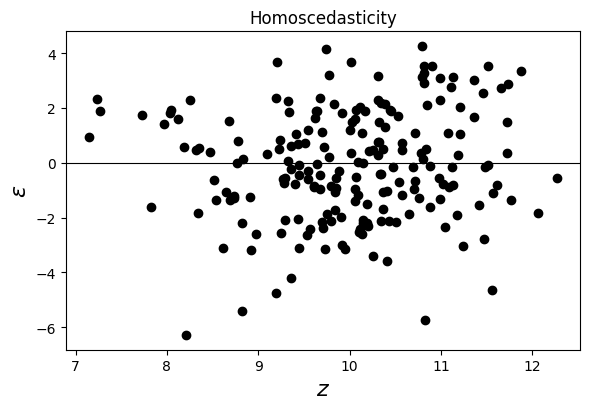

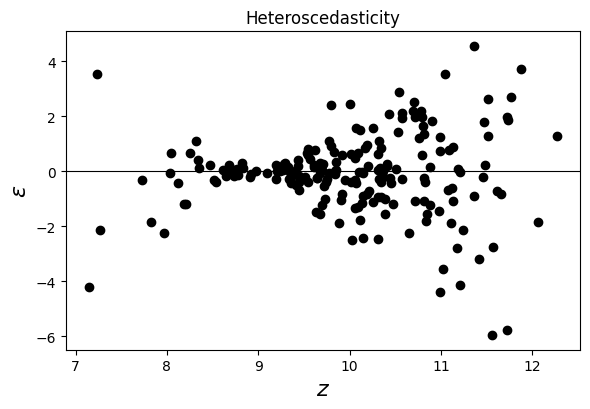

    beta       se   se_rob
0.900523 0.105226 0.105084
2.064279 0.104287 0.086940
2.048606 0.105342 0.148035


In [3]:
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(10 + x[:, k - 2], eho, 'ko', markerfacecolor='k')
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel('$z$', fontsize=16)
ax.set_ylabel(r'$\epsilon$', fontsize=16)
ax.set_title('Homoscedasticity')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(10 + x[:, k - 2], ehe, 'ko', markerfacecolor='k')
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel('$z$', fontsize=16)
ax.set_ylabel(r'$\epsilon$', fontsize=16)
ax.set_title('Heteroscedasticity')
plt.tight_layout()
plt.show()

# Estimate OLS
X = np.column_stack([np.ones(n), x])
beta, sigma, e, se, se_rob = my_ols(y, X)
t = pd.DataFrame({'beta': beta, 'se': se, 'se_rob': se_rob})
print(t.to_string(index=False))


Visual Inspection

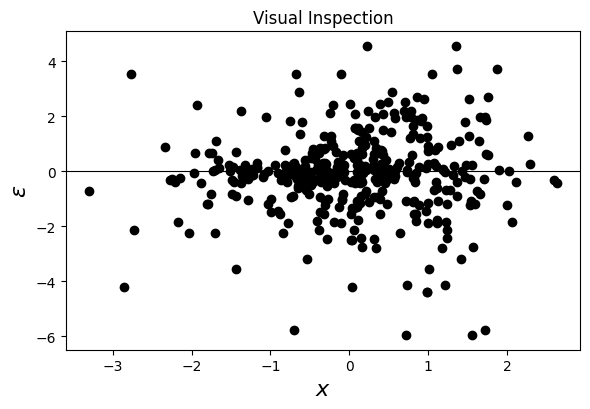

In [4]:
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(x[:, 0], ehe, 'ko', markerfacecolor='k')
ax.plot(x[:, 1], ehe, 'ko', markerfacecolor='k')
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel('$x$', fontsize=16)
ax.set_ylabel(r'$\epsilon$', fontsize=16)
ax.set_title('Visual Inspection')
plt.tight_layout()
plt.show()


**White Test**

$H_{0}:$ Homoscedasticity

In [5]:
value, pvalue = my_white(e, X)
t = pd.DataFrame({'pvalue': [pvalue]})
print(t.to_string(index=False))
if pvalue < 0.05:
    print('Reject Homoscedasticity')
else:
    print('Cannot Reject Homoscedasticity')


  pvalue
0.000279
Reject Homoscedasticity


**Estimate GLS**

In [6]:
beta_gls, e_gls, se_gls = my_gls(y, X, het=True)

betas_1 = [beta[1], np.nan, beta_gls[1]]
method = ['OLS', 'E-White', 'FGLS']
s_err = [se[1], se_rob[1], se_gls[1]]
t = pd.DataFrame({'method': method, 'betas_1': betas_1, 's_err': s_err})
print(t.to_string(index=False))


 method  betas_1    s_err
    OLS 2.064279 0.104287
E-White      NaN 0.086940
   FGLS 2.068501 0.004245


Let's Compute Bootstrap SE

In [7]:
B = 1000
K = k
hbeta_sample = np.empty((B, K))

for i in range(B):
    I_sample = rng.integers(0, n, size=n)
    ysample = y[I_sample]
    xsample = x[I_sample, :]
    Xsample = np.column_stack([np.ones(n), xsample])
    hbeta_sample[i, :] = np.linalg.lstsq(Xsample, ysample, rcond=None)[0]

diff = hbeta_sample - beta
bootVCV = (diff.T @ diff) / B
SEbeta_hat_boot = np.sqrt(np.diag(bootVCV))

print('Results Using Our Functions')
betas_1 = [beta[1], np.nan, beta_gls[1], hbeta_sample[:, 1].mean()]
method = ['OLS', 'E-White', 'FGLS', 'Bootstrap']
s_err = [se[1], se_rob[1], se_gls[1], SEbeta_hat_boot[1]]
t = pd.DataFrame({'method': method, 'betas_1': betas_1, 's_err': s_err})
print(t.to_string(index=False))


Results Using Our Functions
   method  betas_1    s_err
      OLS 2.064279 0.104287
  E-White      NaN 0.086940
     FGLS 2.068501 0.004245
Bootstrap 2.067014 0.089710


In [8]:
# Compare with the standard library:
ols_sm = sm.OLS(y, X).fit()
white_sm = sm.OLS(y, X).fit(cov_type='HC0')
fgls_sm = sm.WLS(y, X, weights=1 / e ** 2).fit()

print('Results Using the Standard Library')
betas_1 = [ols_sm.params[1], np.nan, fgls_sm.params[1]]
method = ['OLS', 'E-White', 'FGLS']
s_err = [ols_sm.bse[1], white_sm.bse[1], fgls_sm.bse[1]]
t = pd.DataFrame({'method': method, 'betas_1': betas_1, 's_err': s_err})
print(t.to_string(index=False))


Results Using the Standard Library
 method  betas_1    s_err
    OLS 2.064279 0.105078
E-White      NaN 0.086940
   FGLS 2.068501 0.004277


**1.2: With Uniform Errors:**

Consider the model

$$y_{i} = \beta_{0}+\beta_{1}x1_{i}+\beta_{2}x2_{i}+\epsilon_{i}$$

$$x\sim \mathcal{N}(0,\sigma^{2})\quad\text{and}\quad\epsilon \sim U[-z,z]$$

Estimate OLS

In [9]:
ub, lb = 100.0, 0.0
aux_z = rng.random(n) * 7

ehe = (20 + 10 * aux_z) * (rng.random(n) - 0.5)
x = np.empty((n, 2))
x[:, 0] = rng.uniform(lb, ub, n)
x[:, 1] = aux_z
y = beta0 + beta1 * x[:, 0] + beta1 * x[:, 1] + ehe

k = 3
ehe = (1 + x[:, k - 2]) * (rng.random(n) - 0.5)   # heteroscedastic errors
y = beta0 + beta1 * x[:, 0] + beta1 * x[:, 1] + ehe

X = np.column_stack([np.ones(n), x])
beta, sigma, e, se, se_rob = my_ols(y, X)


Visual Inspection

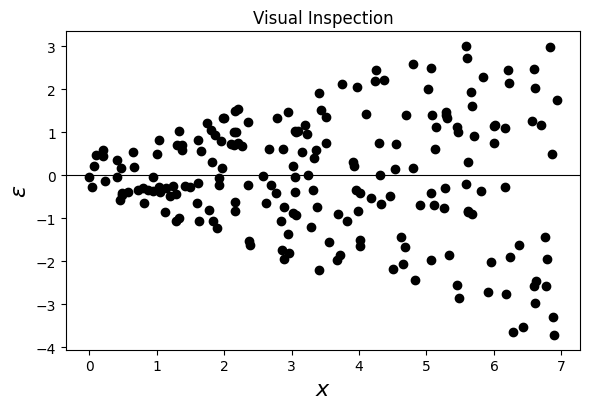

In [10]:
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(x[:, 1], ehe, 'ko', markerfacecolor='k')
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel('$x$', fontsize=16)
ax.set_ylabel(r'$\epsilon$', fontsize=16)
ax.set_title('Visual Inspection')
plt.tight_layout()
plt.show()


**White Test**

$H_{0}:$ Homoscedasticity

In [11]:
value, pvalue = my_white(e, X)
t = pd.DataFrame({'pvalue': [pvalue]})
print(t.to_string(index=False))
if pvalue < 0.05:
    print('Reject Homoscedasticity')
else:
    print('Cannot Reject Homoscedasticity')


      pvalue
5.551115e-15


Reject Homoscedasticity


Estimate GLS and Bootstrap SE

In [12]:
beta_gls, _, se_gls = my_gls(y, X, het=True)

B = 1000
K = k
hbeta_sample = np.empty((B, K))
for i in range(B):
    I_sample = rng.integers(0, n, size=n)
    ysample = y[I_sample]
    xsample = x[I_sample, :]
    Xsample = np.column_stack([np.ones(n), xsample])
    hbeta_sample[i, :] = np.linalg.lstsq(Xsample, ysample, rcond=None)[0]

diff = hbeta_sample - beta
bootVCV = (diff.T @ diff) / B
SEbeta_hat_boot = np.sqrt(np.diag(bootVCV))

print('Results Using our own functions')
betas_1 = [beta[1], np.nan, beta_gls[1], hbeta_sample[:, 1].mean()]
method = ['OLS', 'E-White', 'FGLS', 'Bootstrap']
s_err = [se[1], se_rob[1], se_gls[1], SEbeta_hat_boot[1]]
t = pd.DataFrame({'method': method, 'betas_1': betas_1, 's_err': s_err})
print(t.to_string(index=False))


Results Using our own functions
   method  betas_1    s_err
      OLS 1.998243 0.003451
  E-White      NaN 0.003481
     FGLS 1.997234 0.000518
Bootstrap 1.998202 0.003535


In [13]:
# Compare with the standard library:
ols_sm = sm.OLS(y, X).fit()
white_sm = sm.OLS(y, X).fit(cov_type='HC0')
fgls_sm = sm.WLS(y, X, weights=1 / e ** 2).fit()

print('Results Using the Standard Library')
betas_1 = [ols_sm.params[1], np.nan, fgls_sm.params[1]]
method = ['OLS', 'E-White', 'FGLS']
s_err = [ols_sm.bse[1], white_sm.bse[1], fgls_sm.bse[1]]
t = pd.DataFrame({'method': method, 'betas_1': betas_1, 's_err': s_err})
print(t.to_string(index=False))


Results Using the Standard Library
 method  betas_1    s_err
    OLS 1.998243 0.003477
E-White      NaN 0.003481
   FGLS 1.997234 0.000522


**Activity 2: Autocorrelated Errors**

**Simulating AR(1) errors**

Consider the model

$$y_{i} = \beta_{0}+\beta_{1}x_{i}+\epsilon_{i}$$

$$x\sim U[a,b]\quad\text{and}\quad \epsilon_{i} = \rho\epsilon_{i-1}+u$$

and $u \sim \mathcal{N}(0,\sigma^{2})$

$$\Sigma=\left[\begin{array}{ccccc} 1&\rho& \rho^{2}& \dots &\rho^{n-1} \\ \rho&1&\dots&\dots&\rho^{n-2}  \\ \rho^{2}&\vdots&1&\vdots&\vdots \\ \vdots&\vdots&\vdots&1&\rho \\ \rho^{n-1}&\dots&\dots&\dots&1  \end{array}\right]$$

In [14]:
rho = 0.9
eau = np.empty(n)
eau[0] = rng.standard_normal() / np.sqrt(1 - rho ** 2)   # The trend of the AR(1) process
for i in range(1, n):
    eau[i] = rho * eau[i - 1] + 5 * rng.standard_normal()

y = beta0 + beta1 * x[:, 0] + beta1 * x[:, 1] + eau

beta, sigma, e, se, _ = my_ols(y, X)
se_rob = my_newey(e, X, 1)


Visual Inspection

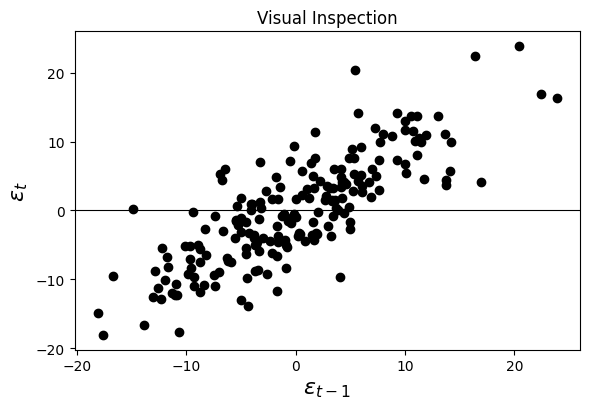

In [15]:
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(e[1:], e[:-1], 'ko', markerfacecolor='k')
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel(r'$\epsilon_{t-1}$', fontsize=16)
ax.set_ylabel(r'$\epsilon_{t}$', fontsize=16)
ax.set_title('Visual Inspection')
plt.tight_layout()
plt.show()


**DW** Durbin Watson

$H_{0}:$ No Autocorrelation

In [16]:
from statsmodels.stats.stattools import durbin_watson

dw_stat = durbin_watson(e)
# Approximate the p-value from the AR(1) coefficient implied by the DW statistic
rho_hat = 1 - dw_stat / 2
z = rho_hat * np.sqrt(n)
pvalue = 2 * (1 - stats.norm.cdf(np.abs(z)))

t = pd.DataFrame({'pvalue': [pvalue]})
print(t.to_string(index=False))
if pvalue < 0.05:
    print('Reject Null: there is autocorrelation')
else:
    print('Cannot Reject Null; There is no autocorrelation')


 pvalue
    0.0
Reject Null: there is autocorrelation


**Estimate GLS and Bootstrap SE**

In [17]:
beta_gls, e_gls, se_gls = my_gls(y, X, het=False)

B = 1000
K = k
hbeta_sample = np.empty((B, K))
for i in range(B):
    I_sample = rng.integers(0, n, size=n)
    ysample = y[I_sample]
    xsample = x[I_sample, :]
    Xsample = np.column_stack([np.ones(n), xsample])
    hbeta_sample[i, :] = np.linalg.lstsq(Xsample, ysample, rcond=None)[0]

diff = hbeta_sample - beta
bootVCV = (diff.T @ diff) / B
SEbeta_hat_boot = np.sqrt(np.diag(bootVCV))

print('Using our functions')
betas_1 = [beta[1], np.nan, beta_gls[1], hbeta_sample[:, 1].mean()]
method = ['OLS', 'Newey West', 'FGLS', 'Bootstrap']
s_err = [se[1], se_rob[1], se_gls[1], SEbeta_hat_boot[1]]
t = pd.DataFrame({'method': method, 'betas_1': betas_1, 's_err': s_err})
print(t.to_string(index=False))


Using our functions
    method  betas_1    s_err
       OLS 2.013705 0.019253
Newey West      NaN 0.020642
      FGLS 2.005814 0.009404
 Bootstrap 2.014528 0.018835


In [18]:
# Compare with the standard library:
lag = int(np.floor(4 * (n / 100) ** (2 / 9))) + 1
ols_sm = sm.OLS(y, X).fit()
nw_sm = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': lag})
fgls_sm = sm.GLSAR(y, X, rho=1).iterative_fit()

print('Results Using the Standard Library')
betas_1 = [ols_sm.params[1], np.nan, fgls_sm.params[1]]
method = ['OLS', 'Newey West', 'FGLS']
s_err = [ols_sm.bse[1], nw_sm.bse[1], fgls_sm.bse[1]]
t = pd.DataFrame({'method': method, 'betas_1': betas_1, 's_err': s_err})
print(t.to_string(index=False))


Results Using the Standard Library
    method  betas_1    s_err
       OLS 2.013705 0.019399
Newey West      NaN 0.020718
      FGLS 2.005365 0.009462


This markdown was constructed based on the IPYNB code below.

In [19]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy import stats
# import statsmodels.api as sm
#
#
# def my_ols(y, x):
#     '''
#     This function computes OLS estimates and
#     its standard errors
#     inputs: y dependent var
#             x independent vars
#     outputs: beta   OLS coefficients
#              sigma  Estimator or variance of error
#              e      Backed residuals
#              se     Standard Errors
#     '''
#     n, k = x.shape
#     beta = np.linalg.lstsq(x, y, rcond=None)[0]
#     e = y - x @ beta
#     sigma = (e @ e) / (n - np.linalg.matrix_rank(x))
#     VCV = (e @ e) / n * np.linalg.inv(x.T @ x)
#     se = np.sqrt(np.diag(VCV))
#
#     # Eicker-White se
#     aux = x * (e ** 2)[:, None]
#     VCV_white = np.linalg.inv(x.T @ x) @ (x.T @ aux) @ np.linalg.inv(x.T @ x)
#     se_rob = np.sqrt(np.diag(VCV_white))
#
#     return beta, sigma, e, se, se_rob
#
#
# def my_gls(y, x, het):
#     '''
#     This function computes GLS estimates and
#     its standard errors
#     inputs: y dependent var
#             x independent vars
#     outputs: beta   OLS coefficients
#              sigma  Estimator or variance of error
#              e      Backed residuals
#              se     Standard Errors
#     '''
#     n = x.shape[0]
#     if het:
#         # Traditional heteroskedasticity
#         _, _, e_ols, _, _ = my_ols(y, x)
#         e_ols = e_ols ** 2
#         # C = diag(1./ sqrt(e_ols));
#         L = np.linalg.cholesky(np.linalg.inv(np.diag(e_ols)))
#         C = L.T
#         beta, _, e, se, _ = my_ols(C @ y, C @ x)
#     else:
#         # AR(1) Errors
#         _, _, e_ols, _, _ = my_ols(y, x)
#
#         # estimation of AR(1) coefficient
#         ey = e_ols[1:n]
#         ex = e_ols[0:n - 1]
#         rho = (ex @ ey) / (ex @ ex)    # Estimating the autocorrelation coeff
#         e_auto = ey - ex * rho
#         var_e = e_auto.var(ddof=0)
#
#         # factor = eye(n).*var_e./(1-rho^2);     % Cancels out
#         sigma_e = np.eye(n)
#         for i in range(n):
#             for j in range(i + 1, n):
#                 sigma_e[i, j] = rho ** (j - i)
#                 sigma_e[j, i] = sigma_e[i, j]
#         # sigma_e = factor.*sigma_e;
#         L = np.linalg.cholesky(np.linalg.inv(sigma_e))
#         C = L.T
#         beta, _, e, se, _ = my_ols(C @ y, C @ x)
#
#     return beta, e, se
#
#
# def my_white(e, x):
#     '''
#     White's test for heteroscedasticity
#     Input:
#     e: Residuals
#     x: Independent Variables
#     '''
#     n = e.shape[0]
#     k = x.shape[1] - 1
#     _, _, e_ols, _, _ = my_ols(e ** 2, x)
#     TSS = e ** 2 - (e ** 2).mean()
#     TSS = TSS @ TSS
#     ESS = e_ols @ e_ols
#     rsq = 1 - ESS / TSS   # the r-square auxiliary
#     value = n * rsq                    # Statistic
#     pvalue = 1 - stats.chi2.cdf(value, k)   # Value
#     return value, pvalue
#
#
# def my_newey(e, x, lag):
#     '''
#     Compute Newey West Standard errors
#     Input: e: residuals
#            x: Matrix of regressors
#            lag: number of lags
#     '''
#     N, k = x.shape
#     VT = np.zeros((k, k))     # This I will fill on a loop,
#     for s in range(lag + 1):
#         omega_s = 1 - s / (lag + 1)
#         for t in range(s, N):
#             if s == 0:
#                 VT = VT + e[t] ** 2 * np.outer(x[t, :], x[t, :])
#             else:               # This calculates the off-diagonal terms
#                 VT = VT + omega_s * e[t] * e[t - s] * (np.outer(x[t, :], x[t - s, :]) + np.outer(x[t - s, :], x[t, :]))
#     VT = (1 / (N - k)) * VT
#     xx_inv = np.linalg.inv(x.T @ x)
#     se = np.sqrt(np.diag(N * (xx_inv @ VT @ xx_inv)))
#     return se
#
#
# # ----- next cell -----
#
# rng = np.random.default_rng(123)
#
# # Parameters
# beta0 = 1.0      # Intercept
# beta1 = 2.0      # Slope
# n = 200
#
# # Simulate the Data Generating process
# k = 3
# x = rng.standard_normal((n, k - 1))
# eho = 2 * rng.standard_normal(n)                       # homoscedastic errors, for comparison
# ehe = (1 + x[:, k - 2]) * rng.standard_normal(n)       # heteroscedastic errors
# y = beta0 + beta1 * x[:, 0] + beta1 * x[:, 1] + ehe
#
#
# # ----- next cell -----
#
# fig, ax = plt.subplots(figsize=(6, 4.2))
# ax.plot(10 + x[:, k - 2], eho, 'ko', markerfacecolor='k')
# ax.axhline(0, color='k', linewidth=0.8)
# ax.set_xlabel('$z$', fontsize=16)
# ax.set_ylabel(r'$\epsilon$', fontsize=16)
# ax.set_title('Homoscedasticity')
# plt.tight_layout()
# plt.show()
#
# fig, ax = plt.subplots(figsize=(6, 4.2))
# ax.plot(10 + x[:, k - 2], ehe, 'ko', markerfacecolor='k')
# ax.axhline(0, color='k', linewidth=0.8)
# ax.set_xlabel('$z$', fontsize=16)
# ax.set_ylabel(r'$\epsilon$', fontsize=16)
# ax.set_title('Heteroscedasticity')
# plt.tight_layout()
# plt.show()
#
# # Estimate OLS
# X = np.column_stack([np.ones(n), x])
# beta, sigma, e, se, se_rob = my_ols(y, X)
# t = pd.DataFrame({'beta': beta, 'se': se, 'se_rob': se_rob})
# print(t.to_string(index=False))
#
#
# # ----- next cell -----
#
# fig, ax = plt.subplots(figsize=(6, 4.2))
# ax.plot(x[:, 0], ehe, 'ko', markerfacecolor='k')
# ax.plot(x[:, 1], ehe, 'ko', markerfacecolor='k')
# ax.axhline(0, color='k', linewidth=0.8)
# ax.set_xlabel('$x$', fontsize=16)
# ax.set_ylabel(r'$\epsilon$', fontsize=16)
# ax.set_title('Visual Inspection')
# plt.tight_layout()
# plt.show()
#
#
# # ----- next cell -----
#
# value, pvalue = my_white(e, X)
# t = pd.DataFrame({'pvalue': [pvalue]})
# print(t.to_string(index=False))
# if pvalue < 0.05:
#     print('Reject Homoscedasticity')
# else:
#     print('Cannot Reject Homoscedasticity')
#
#
# # ----- next cell -----
#
# beta_gls, e_gls, se_gls = my_gls(y, X, het=True)
#
# betas_1 = [beta[1], np.nan, beta_gls[1]]
# method = ['OLS', 'E-White', 'FGLS']
# s_err = [se[1], se_rob[1], se_gls[1]]
# t = pd.DataFrame({'method': method, 'betas_1': betas_1, 's_err': s_err})
# print(t.to_string(index=False))
#
#
# # ----- next cell -----
#
# B = 1000
# K = k
# hbeta_sample = np.empty((B, K))
#
# for i in range(B):
#     I_sample = rng.integers(0, n, size=n)
#     ysample = y[I_sample]
#     xsample = x[I_sample, :]
#     Xsample = np.column_stack([np.ones(n), xsample])
#     hbeta_sample[i, :] = np.linalg.lstsq(Xsample, ysample, rcond=None)[0]
#
# diff = hbeta_sample - beta
# bootVCV = (diff.T @ diff) / B
# SEbeta_hat_boot = np.sqrt(np.diag(bootVCV))
#
# print('Results Using Our Functions')
# betas_1 = [beta[1], np.nan, beta_gls[1], hbeta_sample[:, 1].mean()]
# method = ['OLS', 'E-White', 'FGLS', 'Bootstrap']
# s_err = [se[1], se_rob[1], se_gls[1], SEbeta_hat_boot[1]]
# t = pd.DataFrame({'method': method, 'betas_1': betas_1, 's_err': s_err})
# print(t.to_string(index=False))
#
#
# # ----- next cell -----
#
# # Compare with the standard library:
# ols_sm = sm.OLS(y, X).fit()
# white_sm = sm.OLS(y, X).fit(cov_type='HC0')
# fgls_sm = sm.WLS(y, X, weights=1 / e ** 2).fit()
#
# print('Results Using the Standard Library')
# betas_1 = [ols_sm.params[1], np.nan, fgls_sm.params[1]]
# method = ['OLS', 'E-White', 'FGLS']
# s_err = [ols_sm.bse[1], white_sm.bse[1], fgls_sm.bse[1]]
# t = pd.DataFrame({'method': method, 'betas_1': betas_1, 's_err': s_err})
# print(t.to_string(index=False))
#
#
# # ----- next cell -----
#
# ub, lb = 100.0, 0.0
# aux_z = rng.random(n) * 7
#
# ehe = (20 + 10 * aux_z) * (rng.random(n) - 0.5)
# x = np.empty((n, 2))
# x[:, 0] = rng.uniform(lb, ub, n)
# x[:, 1] = aux_z
# y = beta0 + beta1 * x[:, 0] + beta1 * x[:, 1] + ehe
#
# k = 3
# ehe = (1 + x[:, k - 2]) * (rng.random(n) - 0.5)   # heteroscedastic errors
# y = beta0 + beta1 * x[:, 0] + beta1 * x[:, 1] + ehe
#
# X = np.column_stack([np.ones(n), x])
# beta, sigma, e, se, se_rob = my_ols(y, X)
#
#
# # ----- next cell -----
#
# fig, ax = plt.subplots(figsize=(6, 4.2))
# ax.plot(x[:, 1], ehe, 'ko', markerfacecolor='k')
# ax.axhline(0, color='k', linewidth=0.8)
# ax.set_xlabel('$x$', fontsize=16)
# ax.set_ylabel(r'$\epsilon$', fontsize=16)
# ax.set_title('Visual Inspection')
# plt.tight_layout()
# plt.show()
#
#
# # ----- next cell -----
#
# value, pvalue = my_white(e, X)
# t = pd.DataFrame({'pvalue': [pvalue]})
# print(t.to_string(index=False))
# if pvalue < 0.05:
#     print('Reject Homoscedasticity')
# else:
#     print('Cannot Reject Homoscedasticity')
#
#
# # ----- next cell -----
#
# beta_gls, _, se_gls = my_gls(y, X, het=True)
#
# B = 1000
# K = k
# hbeta_sample = np.empty((B, K))
# for i in range(B):
#     I_sample = rng.integers(0, n, size=n)
#     ysample = y[I_sample]
#     xsample = x[I_sample, :]
#     Xsample = np.column_stack([np.ones(n), xsample])
#     hbeta_sample[i, :] = np.linalg.lstsq(Xsample, ysample, rcond=None)[0]
#
# diff = hbeta_sample - beta
# bootVCV = (diff.T @ diff) / B
# SEbeta_hat_boot = np.sqrt(np.diag(bootVCV))
#
# print('Results Using our own functions')
# betas_1 = [beta[1], np.nan, beta_gls[1], hbeta_sample[:, 1].mean()]
# method = ['OLS', 'E-White', 'FGLS', 'Bootstrap']
# s_err = [se[1], se_rob[1], se_gls[1], SEbeta_hat_boot[1]]
# t = pd.DataFrame({'method': method, 'betas_1': betas_1, 's_err': s_err})
# print(t.to_string(index=False))
#
#
# # ----- next cell -----
#
# # Compare with the standard library:
# ols_sm = sm.OLS(y, X).fit()
# white_sm = sm.OLS(y, X).fit(cov_type='HC0')
# fgls_sm = sm.WLS(y, X, weights=1 / e ** 2).fit()
#
# print('Results Using the Standard Library')
# betas_1 = [ols_sm.params[1], np.nan, fgls_sm.params[1]]
# method = ['OLS', 'E-White', 'FGLS']
# s_err = [ols_sm.bse[1], white_sm.bse[1], fgls_sm.bse[1]]
# t = pd.DataFrame({'method': method, 'betas_1': betas_1, 's_err': s_err})
# print(t.to_string(index=False))
#
#
# # ----- next cell -----
#
# rho = 0.9
# eau = np.empty(n)
# eau[0] = rng.standard_normal() / np.sqrt(1 - rho ** 2)   # The trend of the AR(1) process
# for i in range(1, n):
#     eau[i] = rho * eau[i - 1] + 5 * rng.standard_normal()
#
# y = beta0 + beta1 * x[:, 0] + beta1 * x[:, 1] + eau
#
# beta, sigma, e, se, _ = my_ols(y, X)
# se_rob = my_newey(e, X, 1)
#
#
# # ----- next cell -----
#
# fig, ax = plt.subplots(figsize=(6, 4.2))
# ax.plot(e[1:], e[:-1], 'ko', markerfacecolor='k')
# ax.axhline(0, color='k', linewidth=0.8)
# ax.set_xlabel(r'$\epsilon_{t-1}$', fontsize=16)
# ax.set_ylabel(r'$\epsilon_{t}$', fontsize=16)
# ax.set_title('Visual Inspection')
# plt.tight_layout()
# plt.show()
#
#
# # ----- next cell -----
#
# from statsmodels.stats.stattools import durbin_watson
#
# dw_stat = durbin_watson(e)
# # Approximate the p-value from the AR(1) coefficient implied by the DW statistic
# rho_hat = 1 - dw_stat / 2
# z = rho_hat * np.sqrt(n)
# pvalue = 2 * (1 - stats.norm.cdf(np.abs(z)))
#
# t = pd.DataFrame({'pvalue': [pvalue]})
# print(t.to_string(index=False))
# if pvalue < 0.05:
#     print('Reject Null: there is autocorrelation')
# else:
#     print('Cannot Reject Null; There is no autocorrelation')
#
#
# # ----- next cell -----
#
# beta_gls, e_gls, se_gls = my_gls(y, X, het=False)
#
# B = 1000
# K = k
# hbeta_sample = np.empty((B, K))
# for i in range(B):
#     I_sample = rng.integers(0, n, size=n)
#     ysample = y[I_sample]
#     xsample = x[I_sample, :]
#     Xsample = np.column_stack([np.ones(n), xsample])
#     hbeta_sample[i, :] = np.linalg.lstsq(Xsample, ysample, rcond=None)[0]
#
# diff = hbeta_sample - beta
# bootVCV = (diff.T @ diff) / B
# SEbeta_hat_boot = np.sqrt(np.diag(bootVCV))
#
# print('Using our functions')
# betas_1 = [beta[1], np.nan, beta_gls[1], hbeta_sample[:, 1].mean()]
# method = ['OLS', 'Newey West', 'FGLS', 'Bootstrap']
# s_err = [se[1], se_rob[1], se_gls[1], SEbeta_hat_boot[1]]
# t = pd.DataFrame({'method': method, 'betas_1': betas_1, 's_err': s_err})
# print(t.to_string(index=False))
#
#
# # ----- next cell -----
#
# # Compare with the standard library:
# lag = int(np.floor(4 * (n / 100) ** (2 / 9))) + 1
# ols_sm = sm.OLS(y, X).fit()
# nw_sm = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': lag})
# fgls_sm = sm.GLSAR(y, X, rho=1).iterative_fit()
#
# print('Results Using the Standard Library')
# betas_1 = [ols_sm.params[1], np.nan, fgls_sm.params[1]]
# method = ['OLS', 'Newey West', 'FGLS']
# s_err = [ols_sm.bse[1], nw_sm.bse[1], fgls_sm.bse[1]]
# t = pd.DataFrame({'method': method, 'betas_1': betas_1, 's_err': s_err})
# print(t.to_string(index=False))